# Страница 1 — Классификация отзывов на медицинские учреждения

Сравниваем три подхода к классификации тональности (~70 тыс. отзывов):

| # | Подход | Модель |
|---|--------|--------|
| 1 | **Baseline** | TF-IDF + Logistic Regression |
| 2 | **RNN** | Bidirectional LSTM (с нуля) |
| 3 | **Transformer** | `cointegrated/rubert-tiny2` (fine-tuning) |

**Метрика:** F1-macro &nbsp;|&nbsp; **Классы:** `positive` = 0, `negative` = 1

In [4]:
import os
import time
import json
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, classification_report

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from collections import Counter

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    DataCollatorWithPadding,
)
from datasets import Dataset as HFDataset

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)} | VRAM: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB')
else:
    print('CPU mode')

MODELS_DIR = '../models'
os.makedirs(MODELS_DIR, exist_ok=True)
print(f'Модели -> {os.path.abspath(MODELS_DIR)}')

GPU: NVIDIA GeForce RTX 4060 Ti | VRAM: 16.0 GB
Модели -> c:\study\NLPproject\NLP_Project\models


## 1. Загрузка и подготовка данных

In [5]:
DATA_PATH = 'healthcare_facilities_reviews.jsonl'
assert os.path.exists(DATA_PATH), f'Файл не найден: {DATA_PATH}'

df = pd.read_json(DATA_PATH, lines=True)

# 0 = positive, 1 = negative
df['label'] = (df['sentiment'] == 'negative').astype(int)
df = df.rename(columns={'content': 'text'})
df_clean = df[['text', 'label']].dropna().copy()
df_clean['text']  = df_clean['text'].astype(str)
df_clean['label'] = df_clean['label'].astype(int)

print(f'Записей: {len(df_clean):,}')
vc = df_clean['label'].value_counts().rename(index={0: 'positive', 1: 'negative'})
print(vc.to_string())
df_clean.head(3)

Записей: 70,597
label
positive    41419
negative    29178


,text,label
0,Огромное спасибо за чудесное удаление двух зуб...,0
1,Хочу выразить особую благодарность замечательн...,0
2,Добрый вечер! Хотелось бы поблагодарить сотруд...,0


In [6]:
# to_numpy() converts PyArrow-backed Series to plain numpy (avoids sklearn indexing error)
texts  = df_clean['text'].to_numpy()
labels = df_clean['label'].to_numpy()

X_train, X_test, y_train, y_test = train_test_split(
    texts, labels, test_size=0.2, random_state=42, stratify=labels
)
print(f'Train: {len(X_train):,}  |  Test: {len(X_test):,}')
print(f'Train  pos/neg: {(y_train==0).sum():,} / {(y_train==1).sum():,}')
print(f'Test   pos/neg: {(y_test==0).sum():,} / {(y_test==1).sum():,}')

Train: 56,477  |  Test: 14,120
Train  pos/neg: 33,135 / 23,342
Test   pos/neg: 8,284 / 5,836


## 2. Baseline — TF-IDF + Logistic Regression

In [7]:
print('=' * 55)
print('  TF-IDF + Logistic Regression')
print('=' * 55)

tfidf = TfidfVectorizer(max_features=50_000, ngram_range=(1, 2), sublinear_tf=True)
X_tr_tfidf = tfidf.fit_transform(X_train)
X_te_tfidf = tfidf.transform(X_test)

t0 = time.time()
logreg = LogisticRegression(max_iter=1000, C=1.0, random_state=42)
logreg.fit(X_tr_tfidf, y_train)
print(f'Обучение: {time.time() - t0:.1f} с')

# Single-sample inference time (100 warmup runs, average)
t0 = time.time()
for _ in range(100):
    _v = tfidf.transform([X_test[0]])
    logreg.predict(_v)
inf_time_lr = (time.time() - t0) / 100 * 1000

y_pred_lr = logreg.predict(X_te_tfidf)
f1_lr     = f1_score(y_test, y_pred_lr, average='macro')

print(f'\nF1-macro  : {f1_lr:.4f}')
print(f'Инференс  : {inf_time_lr:.3f} мс/сэмпл')
print()
print(classification_report(y_test, y_pred_lr, target_names=['positive', 'negative']))

with open(f'{MODELS_DIR}/logreg_tfidf.pkl', 'wb') as f:
    pickle.dump({'tfidf': tfidf, 'model': logreg}, f)
print('Saved: logreg_tfidf.pkl')

  TF-IDF + Logistic Regression
Обучение: 0.3 с

F1-macro  : 0.9475
Инференс  : 0.410 мс/сэмпл

              precision    recall  f1-score   support

    positive       0.96      0.95      0.96      8284
    negative       0.93      0.95      0.94      5836

    accuracy                           0.95     14120
   macro avg       0.95      0.95      0.95     14120
weighted avg       0.95      0.95      0.95     14120

Saved: logreg_tfidf.pkl


## 3. RNN — Bidirectional LSTM

In [8]:
def simple_tokenize(text):
    return text.lower().split()


MAX_VOCAB = 30_000
counter = Counter()
for t in X_train:
    counter.update(simple_tokenize(t))

vocab    = ['<pad>', '<unk>'] + [w for w, _ in counter.most_common(MAX_VOCAB - 2)]
word2idx = {w: i for i, w in enumerate(vocab)}
print(f'Vocab size: {len(vocab):,}')

with open(f'{MODELS_DIR}/lstm_vocab.pkl', 'wb') as f:
    pickle.dump(word2idx, f)
print('Saved: lstm_vocab.pkl')

Vocab size: 30,000
Saved: lstm_vocab.pkl


In [9]:
MAX_LEN_LSTM = 256


class ReviewDataset(Dataset):
    """Vectorises texts into fixed-length integer sequences at construction time."""

    def __init__(self, texts, labels, word2idx, max_len=MAX_LEN_LSTM):
        self.samples = []
        for text, label in zip(texts, labels):
            ids = [word2idx.get(tok, 1) for tok in simple_tokenize(text)[:max_len]]
            ids += [0] * (max_len - len(ids))          # pad to max_len
            self.samples.append((
                torch.tensor(ids,   dtype=torch.long),
                torch.tensor(label, dtype=torch.long),
            ))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        return self.samples[idx]


class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=256,
                 num_classes=2, num_layers=2, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(
            embed_dim, hidden_dim,
            num_layers=num_layers, batch_first=True,
            bidirectional=True, dropout=dropout,
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, x):
        emb = self.dropout(self.embedding(x))
        _, (h, _) = self.lstm(emb)
        # last hidden from both directions
        h = torch.cat([h[-2], h[-1]], dim=1)
        return self.fc(self.dropout(h))


print('Dataset / model classes defined.')

Dataset / model classes defined.


In [10]:
BATCH_SIZE  = 128
EPOCHS_LSTM = 5

print('Building datasets (may take ~1 min)...')
train_ds     = ReviewDataset(X_train, y_train, word2idx)
test_ds      = ReviewDataset(X_test,  y_test,  word2idx)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

lstm_model = LSTMClassifier(len(vocab)).to(device)
optimizer  = torch.optim.Adam(lstm_model.parameters(), lr=1e-3)
criterion  = nn.CrossEntropyLoss()
scheduler  = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=1, factor=0.5)

best_f1_lstm   = 0.0
best_state_lstm = None

print(f'Training LSTM ({EPOCHS_LSTM} epochs)...')
for epoch in range(EPOCHS_LSTM):
    # ---------- train ----------
    lstm_model.train()
    total_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(lstm_model(xb), yb)
        loss.backward()
        nn.utils.clip_grad_norm_(lstm_model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item()
    avg_loss = total_loss / len(train_loader)

    # ---------- eval ----------
    lstm_model.eval()
    preds_ep = []
    with torch.no_grad():
        for xb, _ in test_loader:
            preds_ep.extend(lstm_model(xb.to(device)).argmax(1).cpu().numpy())
    f1_ep = f1_score(y_test, preds_ep, average='macro')
    scheduler.step(1.0 - f1_ep)

    flag = ''
    if f1_ep > best_f1_lstm:
        best_f1_lstm    = f1_ep
        best_state_lstm = {k: v.cpu().clone() for k, v in lstm_model.state_dict().items()}
        flag = '  <-- best'
    print(f'  Epoch {epoch+1}/{EPOCHS_LSTM}  loss={avg_loss:.4f}  f1={f1_ep:.4f}{flag}')

# Load best weights, final evaluation
lstm_model.load_state_dict(best_state_lstm)
lstm_model.eval()
preds_lstm = []
t0 = time.time()
with torch.no_grad():
    for xb, _ in test_loader:
        preds_lstm.extend(lstm_model(xb.to(device)).argmax(1).cpu().numpy())
inf_time_lstm = (time.time() - t0) / len(X_test) * 1000
f1_lstm = f1_score(y_test, preds_lstm, average='macro')

print(f'\nBest LSTM  F1-macro: {f1_lstm:.4f}')
print(f'Inference time     : {inf_time_lstm:.3f} ms/sample')
print()
print(classification_report(y_test, preds_lstm, target_names=['positive', 'negative']))

torch.save({
    'state_dict': best_state_lstm,
    'vocab_size' : len(vocab),
    'embed_dim'  : 128,
    'hidden_dim' : 256,
    'num_classes': 2,
    'num_layers' : 2,
}, f'{MODELS_DIR}/lstm_model.pt')
print('Saved: lstm_model.pt')

Building datasets (may take ~1 min)...
Training LSTM (5 epochs)...
  Epoch 1/5  loss=0.4823  f1=0.8559  <-- best
  Epoch 2/5  loss=0.2755  f1=0.9051  <-- best
  Epoch 3/5  loss=0.1957  f1=0.9220  <-- best
  Epoch 4/5  loss=0.1615  f1=0.9365  <-- best
  Epoch 5/5  loss=0.1362  f1=0.9330

Best LSTM  F1-macro: 0.9365
Inference time     : 0.163 ms/sample

              precision    recall  f1-score   support

    positive       0.95      0.94      0.95      8284
    negative       0.92      0.93      0.93      5836

    accuracy                           0.94     14120
   macro avg       0.94      0.94      0.94     14120
weighted avg       0.94      0.94      0.94     14120

Saved: lstm_model.pt


## 4. Transformer — rubert-tiny2 (fine-tuning)

`cointegrated/rubert-tiny2` — компактный русский BERT (~29M параметров). Хорошо работает на RTX 4060 Ti.

In [11]:
BERT_NAME = 'cointegrated/rubert-tiny2'
print(f'Loading: {BERT_NAME}')

bert_tok = AutoTokenizer.from_pretrained(BERT_NAME)
bert_mdl = AutoModelForSequenceClassification.from_pretrained(BERT_NAME, num_labels=2)

n_params = sum(p.numel() for p in bert_mdl.parameters())
print(f'Parameters: {n_params:,}')


def tokenize_fn(examples):
    return bert_tok(examples['text'], truncation=True, max_length=256)


train_hf = HFDataset.from_dict({'text': X_train.tolist(), 'label': y_train.tolist()})
test_hf  = HFDataset.from_dict({'text': X_test.tolist(),  'label': y_test.tolist()})

train_hf = train_hf.map(tokenize_fn, batched=True, remove_columns=['text'])
test_hf  = test_hf.map(tokenize_fn,  batched=True, remove_columns=['text'])

data_collator = DataCollatorWithPadding(tokenizer=bert_tok)
print('Tokenisation done.')
print('Train features:', list(train_hf.features.keys()))

Loading: cointegrated/rubert-tiny2


Loading weights: 100%|██████████| 55/55 [00:00<00:00, 9053.64it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: cointegrated/rubert-tiny2
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the ch

Parameters: 29,194,394


Map: 100%|██████████| 14120/14120 [00:01<00:00, 13062.22 examples/s]

Tokenisation done.
Train features: ['label', 'input_ids', 'token_type_ids', 'attention_mask']


In [12]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {'f1_macro': f1_score(labels, preds, average='macro')}


training_args = TrainingArguments(
    output_dir=f'{MODELS_DIR}/rubert_ckpt',
    num_train_epochs=3,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    learning_rate=2e-5,
    warmup_ratio=0.1,
    weight_decay=0.01,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1_macro',
    greater_is_better=True,
    logging_steps=200,
    report_to='none',
    fp16=torch.cuda.is_available(),
)

trainer = Trainer(
    model=bert_mdl,
    args=training_args,
    train_dataset=train_hf,
    eval_dataset=test_hf,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

print('Fine-tuning rubert-tiny2 (3 epochs)...')
trainer.train()

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Fine-tuning rubert-tiny2 (3 epochs)...


Epoch,Training Loss,Validation Loss,F1 Macro
1,0.171840,0.162613,0.941593
2,0.133309,0.152292,0.945844
3,0.126142,0.152024,0.947901


Writing model shards: 100%|██████████| 1/1 [00:00<00:00, 12.98it/s]


TrainOutput(global_step=5295, training_loss=0.17565159513997627, metrics={'train_runtime': 402.2051, 'train_samples_per_second': 421.255, 'train_steps_per_second': 13.165, 'total_flos': 623778637444608.0, 'train_loss': 0.17565159513997627, 'epoch': 3.0})

In [13]:
# Evaluate best checkpoint (loaded automatically by load_best_model_at_end=True)
eval_res = trainer.evaluate()
f1_bert  = eval_res['eval_f1_macro']

# Single-sample inference time
bert_mdl.eval()
mdl_device = next(bert_mdl.parameters()).device
_inp = bert_tok(X_test[0], return_tensors='pt', truncation=True, max_length=256)
_inp = {k: v.to(mdl_device) for k, v in _inp.items()}

# warmup
with torch.no_grad():
    bert_mdl(**_inp)

t0 = time.time()
for _ in range(100):
    with torch.no_grad():
        bert_mdl(**_inp)
inf_time_bert = (time.time() - t0) / 100 * 1000

print(f'F1-macro  : {f1_bert:.4f}')
print(f'Inference : {inf_time_bert:.3f} ms/sample')

# Save best model for Streamlit
bert_mdl.save_pretrained(f'{MODELS_DIR}/rubert_finetuned')
bert_tok.save_pretrained(f'{MODELS_DIR}/rubert_finetuned')
print('Saved: rubert_finetuned/')

Training Loss,Validation Loss,Epoch,F1 Macro
0.126142,0.152024,3,0.947901


F1-macro  : 0.9479
Inference : 3.959 ms/sample


Writing model shards: 100%|██████████| 1/1 [00:00<00:00, 11.22it/s]

Saved: rubert_finetuned/


## 5. Итоговое сравнение

Saved: metrics.json


,Модель,F1-macro,Инференс (мс)
0,TF-IDF + LogReg,0.9475,0.410
1,LSTM,0.9365,0.163
2,rubert-tiny2,0.9479,3.959


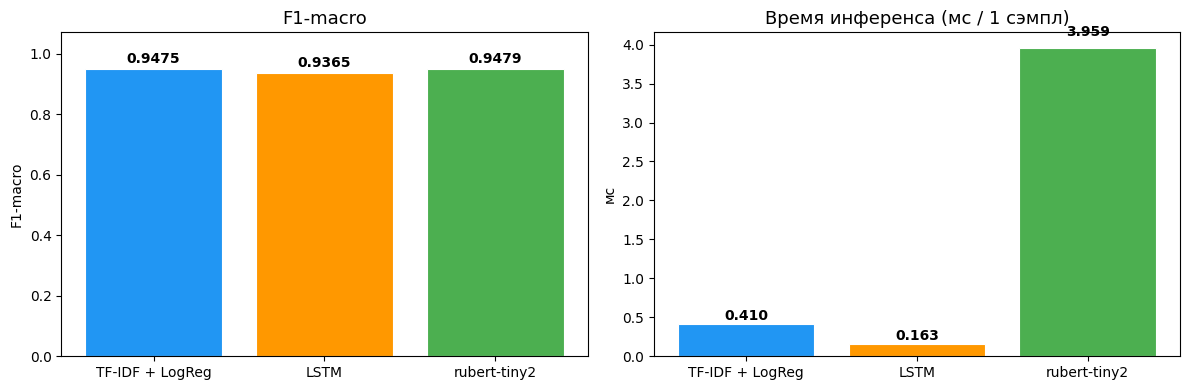

Saved: comparison.png


In [14]:
metrics_data = {
    'logreg': {'name': 'TF-IDF + LogReg', 'f1_macro': float(f1_lr),   'inf_time_ms': float(inf_time_lr)},
    'lstm'  : {'name': 'LSTM',            'f1_macro': float(f1_lstm),  'inf_time_ms': float(inf_time_lstm)},
    'bert'  : {'name': 'rubert-tiny2',    'f1_macro': float(f1_bert),  'inf_time_ms': float(inf_time_bert)},
}

with open(f'{MODELS_DIR}/metrics.json', 'w', encoding='utf-8') as fh:
    json.dump(metrics_data, fh, ensure_ascii=False, indent=2)
print('Saved: metrics.json')

results = pd.DataFrame([
    {'Модель': v['name'], 'F1-macro': round(v['f1_macro'], 4), 'Инференс (мс)': round(v['inf_time_ms'], 3)}
    for v in metrics_data.values()
])
display(results)

# ── charts ──────────────────────────────────────────────────────────────────
names  = [v['name']        for v in metrics_data.values()]
f1s    = [v['f1_macro']    for v in metrics_data.values()]
times  = [v['inf_time_ms'] for v in metrics_data.values()]
colors = ['#2196F3', '#FF9800', '#4CAF50']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

b1 = ax1.bar(names, f1s, color=colors, edgecolor='white', linewidth=0.8)
ax1.set_title('F1-macro', fontsize=13)
ax1.set_ylim(0, 1.07)
ax1.set_ylabel('F1-macro')
for bar, val in zip(b1, f1s):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
             f'{val:.4f}', ha='center', va='bottom', fontweight='bold')

b2 = ax2.bar(names, times, color=colors, edgecolor='white', linewidth=0.8)
ax2.set_title('Время инференса (мс / 1 сэмпл)', fontsize=13)
ax2.set_ylabel('мс')
for bar, val in zip(b2, times):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.03,
             f'{val:.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig(f'{MODELS_DIR}/comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: comparison.png')